# <center>Category 3: Prescriptive Analysis</center>

### 1. Gender vs Time in Hyperglycemia - Do male and female patients spend different amounts of time in hyperglycemia (glucose > 180)?

##### **Reason:** This question helps identify whether male and female patients spend different amounts of time in a hyperglycemic state (glucose > 180 mg/dL). Research suggests that hormonal differences between males and females can influence insulin sensitivity and glucose regulation. In female T1DM patients, fluctuations in estrogen and progesterone levels may contribute to greater variability in blood glucose levels. Comparing hyperglycemia duration between genders in this dataset can help determine whether similar patterns are observed here.

*** Hyperglycemia % per Patient with Gender ***
   patient_id  total_readings  hyper_readings  hyper_percentage  gender
0   HUPA0001P            4096            1723             42.07    Male
1   HUPA0002P            3181             466             14.65    Male
2   HUPA0003P            3770             954             25.31    Male
3   HUPA0004P            3184            1448             45.48  Female
4   HUPA0005P            3858             973             25.22    Male
5   HUPA0006P            2290             809             35.33    Male
6   HUPA0007P            3857            1743             45.19    Male
7   HUPA0009P            3812            2232             58.55  Female
8   HUPA0010P            2976             501             16.83    Male
9   HUPA0011P            3839            1238             32.25  Female
10  HUPA0014P            3829            1987             51.89    Male
11  HUPA0015P            3792            1409             37.16  Female
12  HUPA0016P   

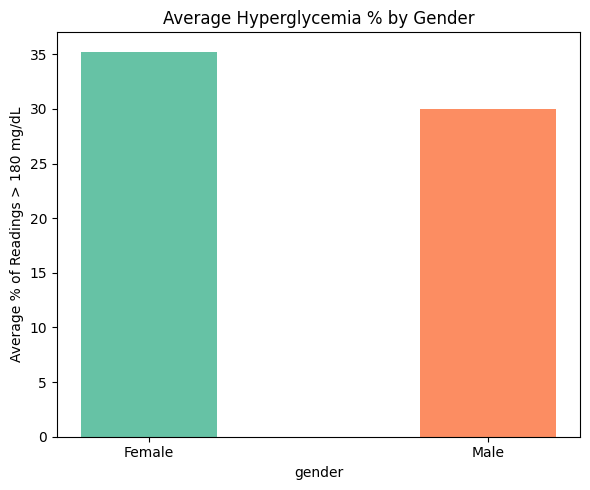

In [1]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)

# Reading file
df_all = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Calculating hyperglycemia readings per patient
total_readings   = df_all.groupby('patient_id')['glucose'].count()
hyper_readings   = df_all[df_all['glucose'] > 180].groupby('patient_id')['glucose'].count()

# Dataframe summary per patient with gender
hyper_summary = pd.DataFrame({
    'total_readings' : total_readings,
    'hyper_readings' : hyper_readings,
    'hyper_percentage': ((hyper_readings / total_readings) * 100).round(2)}).fillna(0).reset_index()

# Adding gender column to the dataframe and merging using left join
patient_gender = df_all[['patient_id', 'gender']].drop_duplicates()
hyper_summary  = hyper_summary.merge(patient_gender, on='patient_id', how='left')

print("*** Hyperglycemia % per Patient with Gender ***")
print(hyper_summary)

# Finding average hyperglycemia % by gender
gender_summary = hyper_summary.groupby('gender')['hyper_percentage'].agg(
    Mean_Hyper_Pct = 'mean',
    Patient_Count  = 'count'
).round(2)

print("\n*** Average % in Hyperglycemia by Gender ***")
print(gender_summary)

# Visualization
# Bar Chart 1 - Average hyperglycemia % by gender
x1 = gender_summary.index
y1 = gender_summary['Mean_Hyper_Pct']

plt.figure(figsize=(6, 5))
plt.bar(x1, y1, width=0.4, color=plt.cm.Set2(range(len(x1))))
plt.title('Average Hyperglycemia % by Gender')
plt.xlabel('gender')
plt.ylabel('Average % of Readings > 180 mg/dL')
plt.tight_layout()
plt.show()

**<span style="color:green">Key Insights: The average hyperglycemia in female patients is 35.25% when compared to male patients which is, 29.96%. In T1DM, hormonal fluctuations in female patients (estrogen and progesterone) are known to affect insulin sensitivity, which can cause unpredictable glucose swings. As seen in the above insights a higher hyperglycemia % in females may reflect these hormonal effects on glucose regulation.  </green>**

### 2. Basal Rate vs Overnight Glucose Stability - Do patients with higher overnight basal rates have more stable glucose between 12AM–6AM?

##### **Reason:** This question is important because the primary purpose of basal insulin is to maintain stable glucose levels during fasting periods and sleep. If glucose levels fluctuate significantly overnight despite a programmed basal rate, it may indicate that the insulin delivery settings are not properly calibrated for the patient’s physiological needs. Ideally, comparing basal rate levels to overnight glucose variance should directly test whether the pump settings are working as intended.

In [2]:
# Reading file
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Filtering overnight readings (12AM - 6AM)
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time
overnight  = df[df['time'].apply(lambda x: x >= pd.Timestamp('00:00').time() and x <= pd.Timestamp('06:00').time())]

print(f"Total overnight readings : {len(overnight)}")

# Calculating glucose stability (standard deviation) per patient overnight
overnight_stability = overnight.groupby('patient_id').agg(
    avg_glucose     = ('glucose',    'mean'),
    std_glucose     = ('glucose',    'std'),
    avg_basal_rate  = ('basal_rate', 'mean')
).round(2).reset_index()

# Sorting by average standard deviation glucose descending
overnight_stability = overnight_stability.sort_values(
    by='std_glucose',
    ascending=False
)

print("\n*** Overnight Glucose Stability per Patient ***")
print(overnight_stability)

Total overnight readings : 78173

*** Overnight Glucose Stability per Patient ***
   patient_id  avg_glucose  std_glucose  avg_basal_rate
5   HUPA0006P       153.10        96.78            0.08
12  HUPA0016P       165.11        89.90            0.09
16  HUPA0020P       217.86        84.06            0.08
2   HUPA0003P       150.45        81.78            0.06
10  HUPA0014P       212.99        79.90            0.00
6   HUPA0007P       144.08        78.54            0.09
20  HUPA0024P       157.35        76.07            0.04
0   HUPA0001P       173.11        76.05            0.05
3   HUPA0004P       141.91        69.19            0.08
15  HUPA0019P       171.45        68.02            0.06
14  HUPA0018P       175.90        67.73            0.00
22  HUPA0026P       159.14        67.18            0.04
13  HUPA0017P       223.92        59.21            0.06
1   HUPA0002P       104.22        56.67            0.08
11  HUPA0015P       156.60        53.56            0.00
8   HUPA0010P       11

**<span style="color:green">Key Insights: The overnight glucose analysis revealed substantial variability in glucose stability across patients. Patients such as HUPA0006P, HUPA0016P, and HUPA0020P exhibited high glucose standard deviations, indicating unstable overnight glycemic control. However, higher glucose variability did not consistently correspond to lower or higher basal insulin rates. For example, patients HUPA0022P and HUPA0025P maintained comparatively lower glucose variability despite receiving relatively higher basal rates. These findings suggest that overnight glucose stability may be influenced by multiple factors beyond basal insulin dosing alone, including insulin sensitivity, meal timing, lifestyle behaviors, and correction bolus administration.</green>**

### 3. Does Carb Intake Cause a Glucose Spike in the Next Interval?

##### **Reason:**
Carbohydrates are broken down into glucose and absorbed into the bloodstream 
within 15–30 minutes. In T1DM patients without adequate bolus coverage, this 
causes a measurable spike. The 5-minute interval data lets us observe this 
effect almost in real time.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")
print(df.shape)
print(df.columns.tolist())

(309392, 16)
['glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input', 'patient_id', 'date', 'time', 'age', 'gender', 'race', 'average_sleep_duration_(hrs)', 'sleep_quality_(1-10)', '%_with_sleep_disturbances']


Correlation between carb input and glucose rise:
              carb_input  glucose_rise
carb_input      1.000000     -0.198452
glucose_rise   -0.198452      1.000000
Mean glucose rise after carb event: 1.14 mg/dL


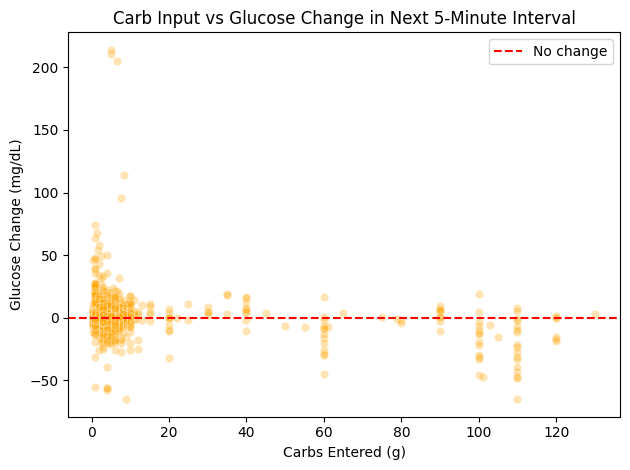

In [6]:
df_sorted = df.sort_values(['patient_id', 'date', 'time']).copy()
df_sorted['next_glucose'] = df_sorted.groupby('patient_id')['glucose'].shift(-1)
df_sorted['glucose_rise'] = df_sorted['next_glucose'] - df_sorted['glucose']

meals = df_sorted[df_sorted['carb_input'] > 0].dropna(subset=['glucose_rise'])

print("Correlation between carb input and glucose rise:")
print(meals[['carb_input', 'glucose_rise']].corr())
print(f"Mean glucose rise after carb event: {meals['glucose_rise'].mean():.2f} mg/dL")

sns.scatterplot(data=meals, x='carb_input', y='glucose_rise', alpha=0.3, color='orange')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Carb Input vs Glucose Change in Next 5-Minute Interval")
plt.xlabel("Carbs Entered (g)")
plt.ylabel("Glucose Change (mg/dL)")
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between carb intake 
and glucose rise in the next 5-minute interval is -0.20, which is weak and 
slightly negative. This is clinically explainable — patients often enter carb 
data at the same time as giving a bolus dose, meaning insulin counteracts the 
expected glucose rise within the same interval. The mean glucose change after a 
carb event was only +1.14 mg/dL, suggesting bolus insulin is partially 
offsetting the immediate spike.</span>**

### 4. Does Physical Activity Reduce Glucose in the Following Interval?

##### **Reason:**
Exercise causes muscles to absorb glucose independently of insulin — called 
non-insulin-mediated glucose uptake. For T1DM patients, physical activity is 
one of the most effective natural glucose-lowering mechanisms, but it also 
carries hypoglycemia risk if insulin doses are not adjusted accordingly.

Correlation between steps and glucose change:
                   steps  glucose_change
steps           1.000000       -0.099522
glucose_change -0.099522        1.000000
Mean glucose change during active intervals: -0.26 mg/dL


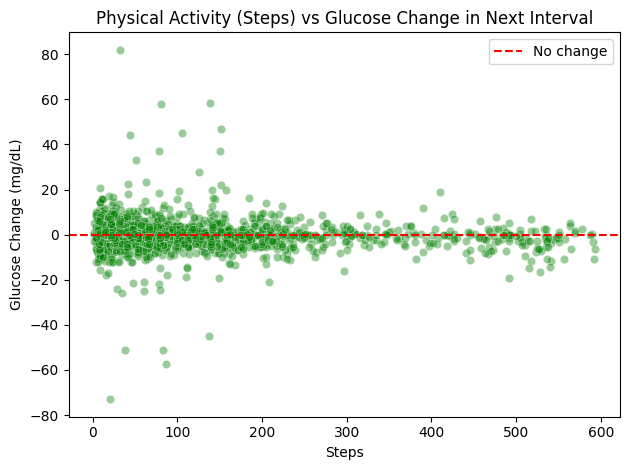

In [7]:
df_sorted['glucose_change'] = df_sorted['next_glucose'] - df_sorted['glucose']
active = df_sorted[df_sorted['steps'] > 0].dropna(subset=['glucose_change'])

print("Correlation between steps and glucose change:")
print(active[['steps', 'glucose_change']].corr())
print(f"Mean glucose change during active intervals: {active['glucose_change'].mean():.2f} mg/dL")

sns.scatterplot(data=active.sample(2000, random_state=42),
                x='steps', y='glucose_change', alpha=0.4, color='green')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Physical Activity (Steps) vs Glucose Change in Next Interval")
plt.xlabel("Steps")
plt.ylabel("Glucose Change (mg/dL)")
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between steps and 
glucose change in the next interval is -0.10, indicating a weak negative 
relationship — more steps are associated with a slight glucose decrease. The 
mean glucose change during active intervals was -0.26 mg/dL, confirming a 
small but consistent glucose-lowering effect. While weak at the 5-minute level, 
the glucose-lowering effect of exercise accumulates over longer periods, 
supporting physical activity as part of T1DM glucose management.</span>**

### 5. Do Patients With Poor Sleep Quality Have Higher Average Glucose?

##### **Reason:**
Poor sleep elevates cortisol and growth hormone, both of which increase insulin 
resistance. In T1DM, this makes glucose harder to control even with the same 
insulin doses. Research shows even one night of poor sleep can raise next-day 
glucose significantly.

Correlation matrix:
                    avg_glucose  sleep_quality  sleep_disturbances
avg_glucose            1.000000       0.046668            0.279695
sleep_quality          0.046668       1.000000           -0.037980
sleep_disturbances     0.279695      -0.037980            1.000000


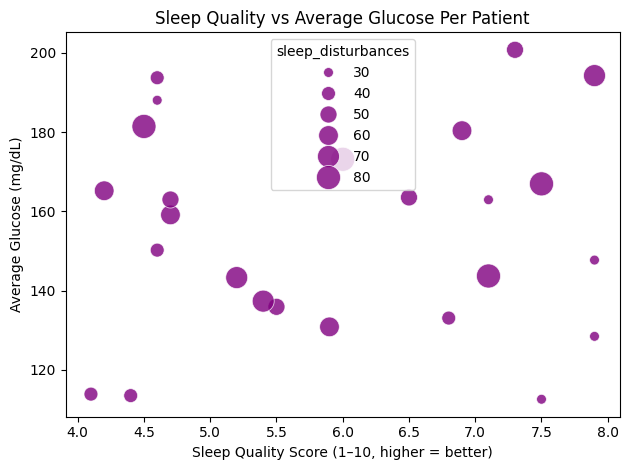

In [8]:
patient_summary = df.groupby('patient_id').agg(
    avg_glucose=('glucose', 'mean'),
    sleep_quality=('sleep_quality_(1-10)', 'first'),
    sleep_disturbances=('%_with_sleep_disturbances', 'first')
).reset_index()

print("Correlation matrix:")
print(patient_summary[['avg_glucose', 'sleep_quality', 'sleep_disturbances']].corr())

sns.scatterplot(data=patient_summary, x='sleep_quality', y='avg_glucose',
                size='sleep_disturbances', sizes=(50, 300),
                alpha=0.8, color='purple')
plt.title("Sleep Quality vs Average Glucose Per Patient")
plt.xlabel("Sleep Quality Score (1–10, higher = better)")
plt.ylabel("Average Glucose (mg/dL)")
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between sleep 
quality and average glucose is only 0.05, suggesting no strong direct 
relationship. However sleep disturbance percentage shows a stronger correlation 
with average glucose at 0.28 — patients with more frequent sleep disruptions 
tend to have higher average glucose. HUPA0017P has the highest average glucose 
(200.80 mg/dL) and a high disturbance rate, while HUPA0022P has one of the 
lowest (112.55 mg/dL) despite a good sleep quality score of 7.5. Sleep 
disturbances may be a more meaningful metric than sleep quality score alone 
for predicting glucose control in T1DM.</span>**

### 6. Does Bolus Insulin Effectively Reduce Glucose After a Meal?

##### **Reason:**
Bolus insulin is specifically delivered to counteract post-meal glucose spikes 
in T1DM pump therapy. A correctly dosed bolus should bring glucose down within 
1–2 hours. This tests whether pump therapy is working as intended and whether 
higher bolus volumes produce proportionally greater glucose reduction.

Correlation between bolus volume and 2-hour glucose change:
                        bolus_volume_delivered  glucose_change_2hr
bolus_volume_delivered                1.000000            0.153089
glucose_change_2hr                    0.153089            1.000000
Mean glucose change 2hrs after bolus: -1.11 mg/dL


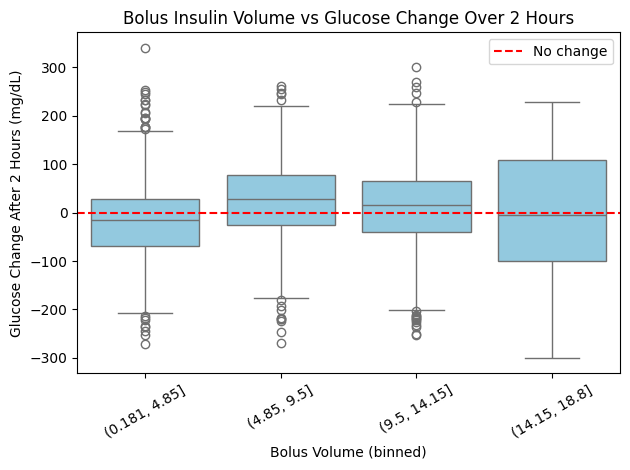

In [9]:
bolus_events = df_sorted[df_sorted['bolus_volume_delivered'] > 0].copy()
bolus_events['glucose_2hrs_later'] = bolus_events.groupby('patient_id')['glucose'].shift(-24)
bolus_events['glucose_change_2hr'] = bolus_events['glucose_2hrs_later'] - bolus_events['glucose']
bolus_events = bolus_events.dropna(subset=['glucose_change_2hr'])

print("Correlation between bolus volume and 2-hour glucose change:")
print(bolus_events[['bolus_volume_delivered', 'glucose_change_2hr']].corr())
print(f"Mean glucose change 2hrs after bolus: {bolus_events['glucose_change_2hr'].mean():.2f} mg/dL")

bolus_events['bolus_bin'] = pd.cut(bolus_events['bolus_volume_delivered'], bins=4)
sns.boxplot(data=bolus_events, x='bolus_bin', y='glucose_change_2hr', color='skyblue')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Bolus Insulin Volume vs Glucose Change Over 2 Hours")
plt.xlabel("Bolus Volume (binned)")
plt.ylabel("Glucose Change After 2 Hours (mg/dL)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between bolus volume 
and glucose change over 2 hours is 0.15, weak but positive — larger bolus doses 
are associated with slightly more glucose reduction. The mean glucose change 
2 hours after a bolus event was -1.11 mg/dL, confirming bolus delivery produces 
a net glucose decrease on average. The weak correlation may reflect variability 
in meal size, timing, and individual insulin sensitivity across the 25 
patients.</span>**

### 7. Are Older Patients Spending More Time in Hyperglycemia?

##### **Reason:**
Older T1DM patients may have had the disease longer, leading to accumulated 
complications, reduced hypoglycemia awareness, and greater insulin resistance 
over time. Time above 180 mg/dL is the primary driver of long-term 
complications like retinopathy, nephropathy, and neuropathy.

Correlation between age and % time in hyperglycemia:
                        age  pct_hyperglycemic
age                1.000000           0.075278
pct_hyperglycemic  0.075278           1.000000


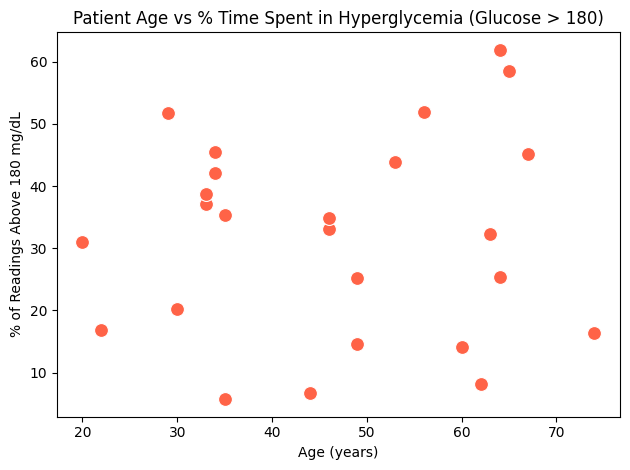

In [10]:
total_readings = df.groupby('patient_id').size()
hyper_readings = df[df['glucose'] > 180].groupby('patient_id').size()
pct_hyper = (hyper_readings / total_readings * 100).fillna(0).round(2)

patient_age = df.drop_duplicates('patient_id').set_index('patient_id')['age']

age_hyper = pd.DataFrame({
    'age': patient_age,
    'pct_hyperglycemic': pct_hyper
}).dropna()

print("Correlation between age and % time in hyperglycemia:")
print(age_hyper.corr())

sns.scatterplot(data=age_hyper, x='age', y='pct_hyperglycemic',
                color='tomato', s=100)
plt.title("Patient Age vs % Time Spent in Hyperglycemia (Glucose > 180)")
plt.xlabel("Age (years)")
plt.ylabel("% of Readings Above 180 mg/dL")
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between age and 
percentage of time in hyperglycemia is 0.08, indicating almost no linear 
relationship. However HUPA0017P (age 64) spent 61.91% of readings above 
180 mg/dL and HUPA0009P (age 65) spent 58.55%, both older patients with very 
high hyperglycemia rates. Meanwhile HUPA0020P (age 29) also had 51.68%, 
showing younger patients can struggle equally. Age alone is not a reliable 
predictor — disease duration, insulin regimen, and lifestyle factors likely 
play a larger role.</span>**

### When should alerts be triggered for Patients?

#### ** Reason **
about a hypothetical diabetic patient, alerts should be triggered when health indicators suggest immediate risk, worsening control, or the need for intervention.
Here are common situations where alerts should be triggered and why:
1. High Blood Glucose Alert
Trigger: Glucose level exceeds a critical threshold (e.g., >180 mg/dL fasting or >250 mg/dL anytime)
Reason:
Persistent hyperglycemia can increase the risk of:
diabetic ketoacidosis,
organ damage,
cardiovascular complications,
hospitalization.
Prescriptive Action:
Recommend insulin adjustment, hydration, medication review, or immediate clinical attention.

3. Low Blood Glucose Alert
Trigger: Glucose drops below ~70 mg/dL
Reason:
Hypoglycemia may cause:
dizziness,
confusion,
seizures,
unconsciousness.
Prescriptive Action:
Consume fast-acting carbohydrates and monitor glucose closely.

In [11]:
# Prescriptive Alert System for a Diabetic Patient
def check_patient_alerts(glucose, heart_rate, activity_minutes):
    alerts = []

    # -----------------------------
    # Glucose Alerts
    # -----------------------------
    if glucose > 250:
        alerts.append(
            "CRITICAL GLUCOSE ALERT: Glucose is extremely high. "
            "Risk of diabetic complications. Immediate medical attention recommended."
        )

    elif glucose > 180:
        alerts.append(
            "HIGH GLUCOSE ALERT: Elevated glucose detected. "
            "Recommend medication review, hydration, and dietary monitoring."
        )

    elif glucose < 70:
        alerts.append(
            "LOW GLUCOSE ALERT: Possible hypoglycemia detected. "
            "Consume fast-acting carbohydrates immediately."
        )

    # -----------------------------
    # Heart Rate Alerts
    # -----------------------------
    if heart_rate > 100:
        alerts.append(
            "HIGH HEART RATE ALERT: Possible stress, dehydration, "
            "or cardiovascular strain detected."
        )

    elif heart_rate < 60:
        alerts.append(
            "LOW HEART RATE ALERT: Possible bradycardia or autonomic dysfunction."
        )

    # -----------------------------
    # Physical Activity Alerts
    # -----------------------------
    if activity_minutes < 30:
        alerts.append(
            "LOW ACTIVITY ALERT: Physical activity is below recommended levels. "
            "Exercise may help improve insulin sensitivity."
        )

    # -----------------------------
    # Final Output
    # -----------------------------
    if alerts:
        print("\n===== PATIENT ALERTS =====\n")

        for i, alert in enumerate(alerts, start=1):
            print(f"{i}. {alert}\n")

    else:
        print("Patient condition appears stable. No critical alerts detected.")


# ---------------------------------------------------
# Example Patient Data
# ---------------------------------------------------

glucose = 210          # mg/dL
heart_rate = 108       # bpm
activity_minutes = 15  # minutes/day

# Run Alert System
check_patient_alerts(
    glucose,
    heart_rate,
    activity_minutes
)


===== PATIENT ALERTS =====

1. HIGH GLUCOSE ALERT: Elevated glucose detected. Recommend medication review, hydration, and dietary monitoring.

2. HIGH HEART RATE ALERT: Possible stress, dehydration, or cardiovascular strain detected.

3. LOW ACTIVITY ALERT: Physical activity is below recommended levels. Exercise may help improve insulin sensitivity.



**<span style="color:green"> Key Insights: The patient shows elevated glucose levels, indicating poor glycemic control and a potential risk of diabetes-related complications if not managed promptly.
The high heart rate suggests possible physiological stress, dehydration, cardiovascular strain, or glucose imbalance, which are commonly associated with uncontrolled diabetes.
The patient’s low physical activity level may be contributing to reduced insulin sensitivity and worsening glucose regulation.
The combination of high glucose + elevated heart rate + low activity indicates that the patient may be at increased metabolic and cardiovascular risk.
Early alerts enable proactive intervention such as:
medication adjustment, increased physical activity, hydration management, dietary improvements,closer clinical monitoring.</span>**

### Question: What is the co-relation between the health metrics glucose, heart rate, steps, calories, sleep quality and % sleep disturbances?

#### **Reason**
to check what precautions and prescriptive actions should we take to gain proper health if positive relation exists between parameters.

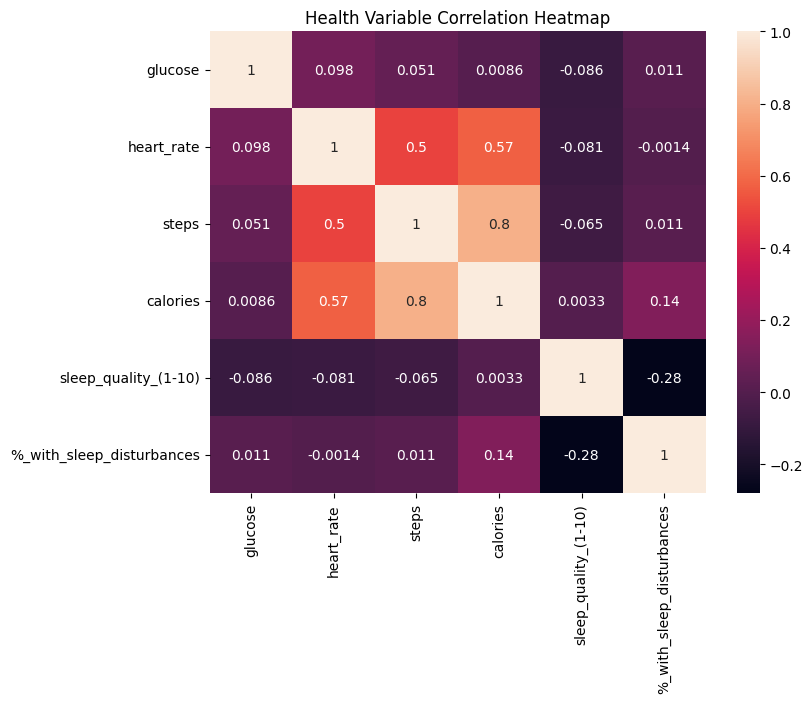

In [15]:
import seaborn as sns

# Select numeric columns
corr = df[['glucose',
           'heart_rate',
           'steps',
           'calories',
           'sleep_quality_(1-10)',
           '%_with_sleep_disturbances']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.title("Health Variable Correlation Heatmap")

plt.show()

**<span style="color:green">
strong relationship between heartrate, steps and calories, 
However, Weak relationship: Glucose with all variables
Glucose has very weak correlation with:
Steps (0.05)
Calories (0.008)
Heart rate (0.09)
Sleep quality (-0.08)

👉 Insight: Glucose is not strongly influenced by single lifestyle variables alone.
</span>**

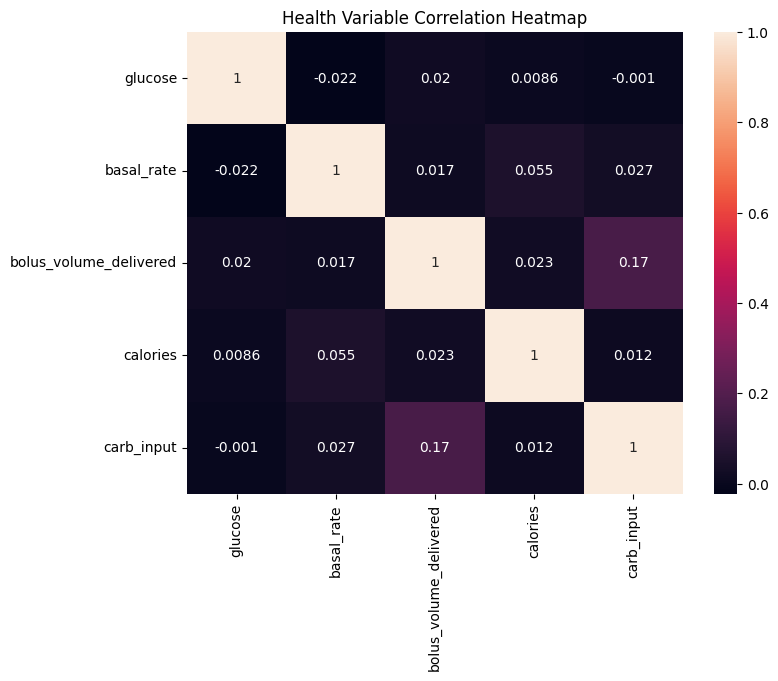

In [16]:
import seaborn as sns

# Select numeric columns
corr = df[['glucose',
           'basal_rate',
           'bolus_volume_delivered',
           'calories',
           'carb_input']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.title("Health Variable Correlation Heatmap")

plt.show()

**<span style="color:green">
Negative co-relation between glucose and other above displayed metrics.
👉 Insight: Glucose is not influenced by single lifestyle variables alone.
</span>**

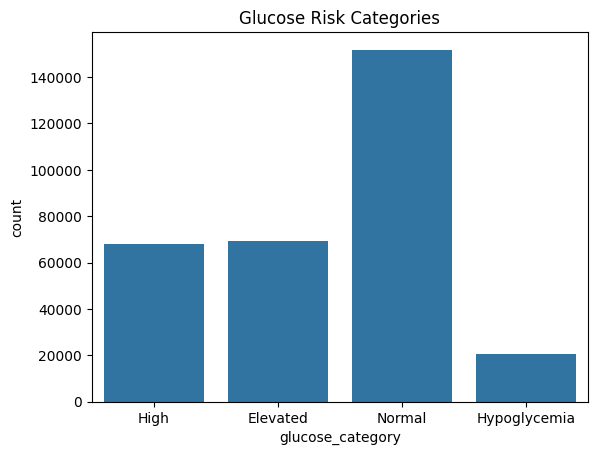

In [17]:
def categorize_glucose(x):
    if x < 70:
        return "Hypoglycemia"
    elif x < 140:
        return "Normal"
    elif x < 180:
        return "Elevated"
    else:
        return "High"

df['glucose_category'] = df['glucose'].apply(categorize_glucose)

sns.countplot(data=df, x='glucose_category')
plt.title("Glucose Risk Categories")
plt.show()

### How glucose is trending throuout a day (Hourly values)?

#### **Reason**
This question helps identify when glucose naturally rises or falls during the day.

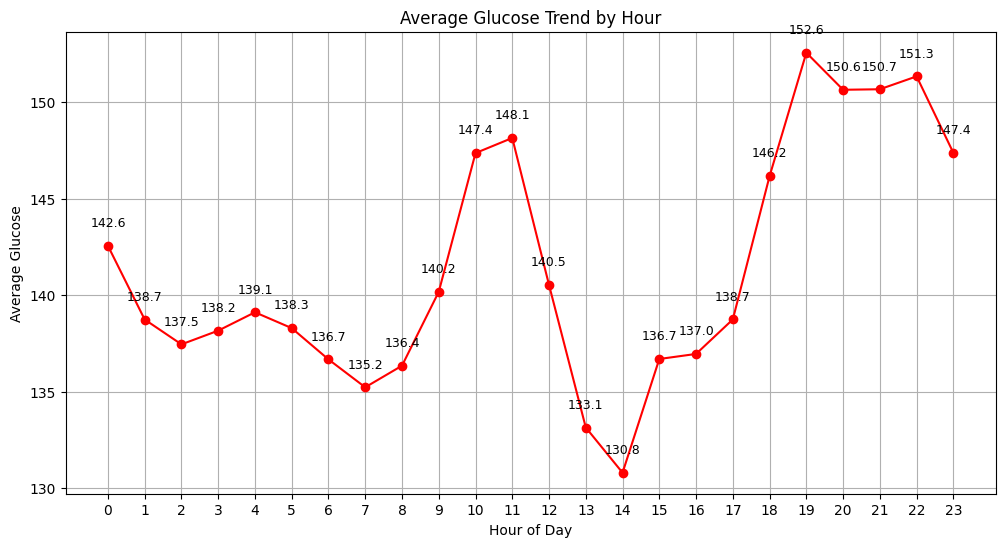

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert time column to datetime format
df['time'] = pd.to_datetime(df['time'])

# Extract hour only
df['hour'] = df['time'].dt.hour

# Average glucose by hour
hourly_glucose = df.groupby('hour')['glucose'].mean()

# Plot
plt.figure(figsize=(12,6))

plt.plot(hourly_glucose.index, hourly_glucose.values, marker='o', color = 'red')
# Add value labels
for x, y in zip(hourly_glucose.index, hourly_glucose.values):
    plt.text(
        x, 
        y + 1,                 # slightly above point
        round(y, 1),           # label text
        ha='center',
        fontsize=9
    )

plt.xlabel("Hour of Day")
plt.ylabel("Average Glucose")
plt.title("Average Glucose Trend by Hour")

# Show all hours clearly
plt.xticks(range(0,24))

plt.grid(True)

plt.show()


**<span style="color:green">
🔺 Highest glucose: Evening hours (19–22), peak around Hour 19 (~152.6) → strong post-dinner spike.
🔻 Lowest glucose: Midday (Hour 14 ~130.8) → most stable period.
🍽️ Clear meal effect: spikes after breakfast and especially dinner.
🌙 Night hours stay relatively high (150+), showing late-night glucose elevation risk.
⚠️ Overall issue: poor evening glucose control compared to daytime stability.
</span>**

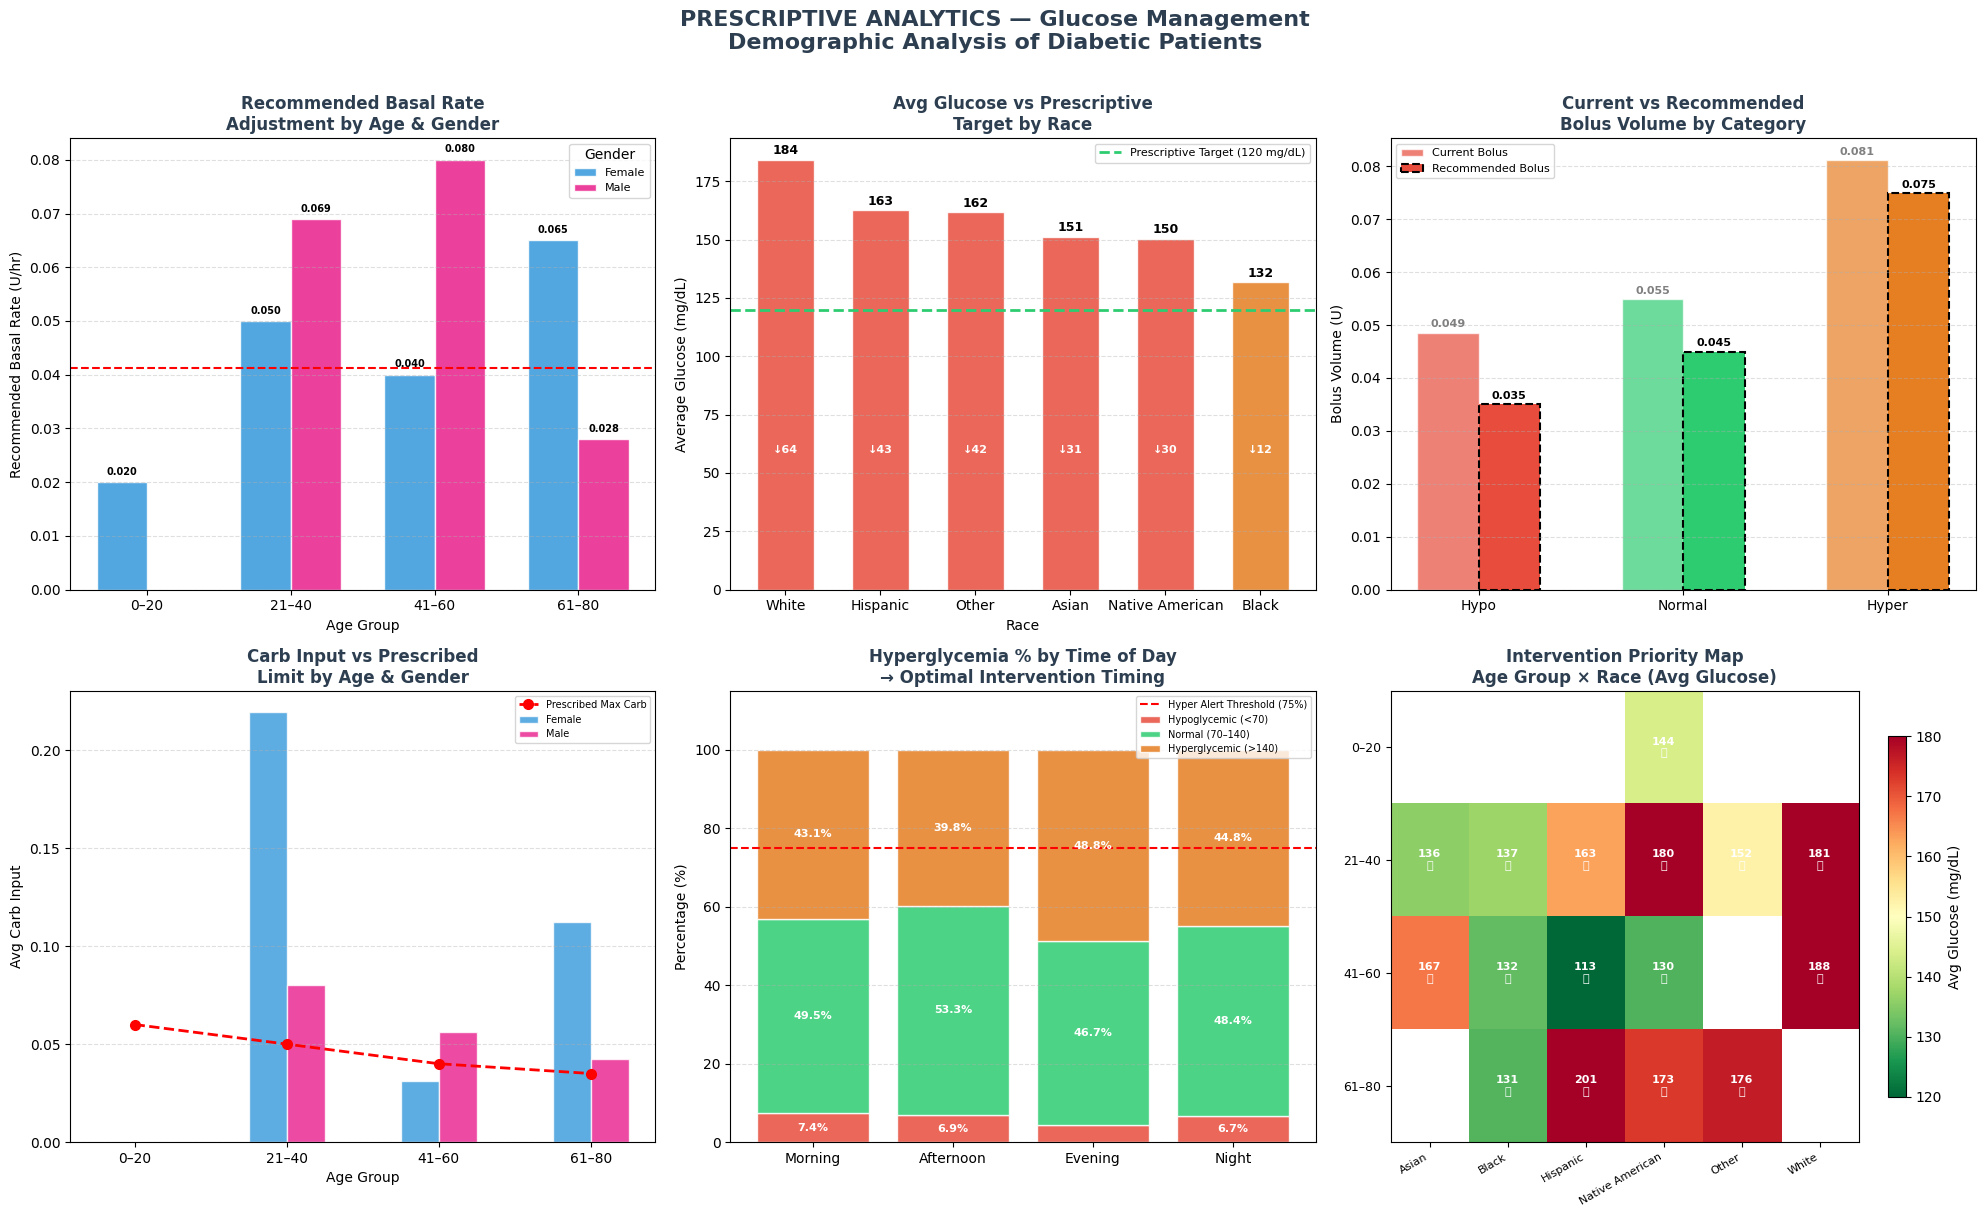

✅ Figure 1 saved.


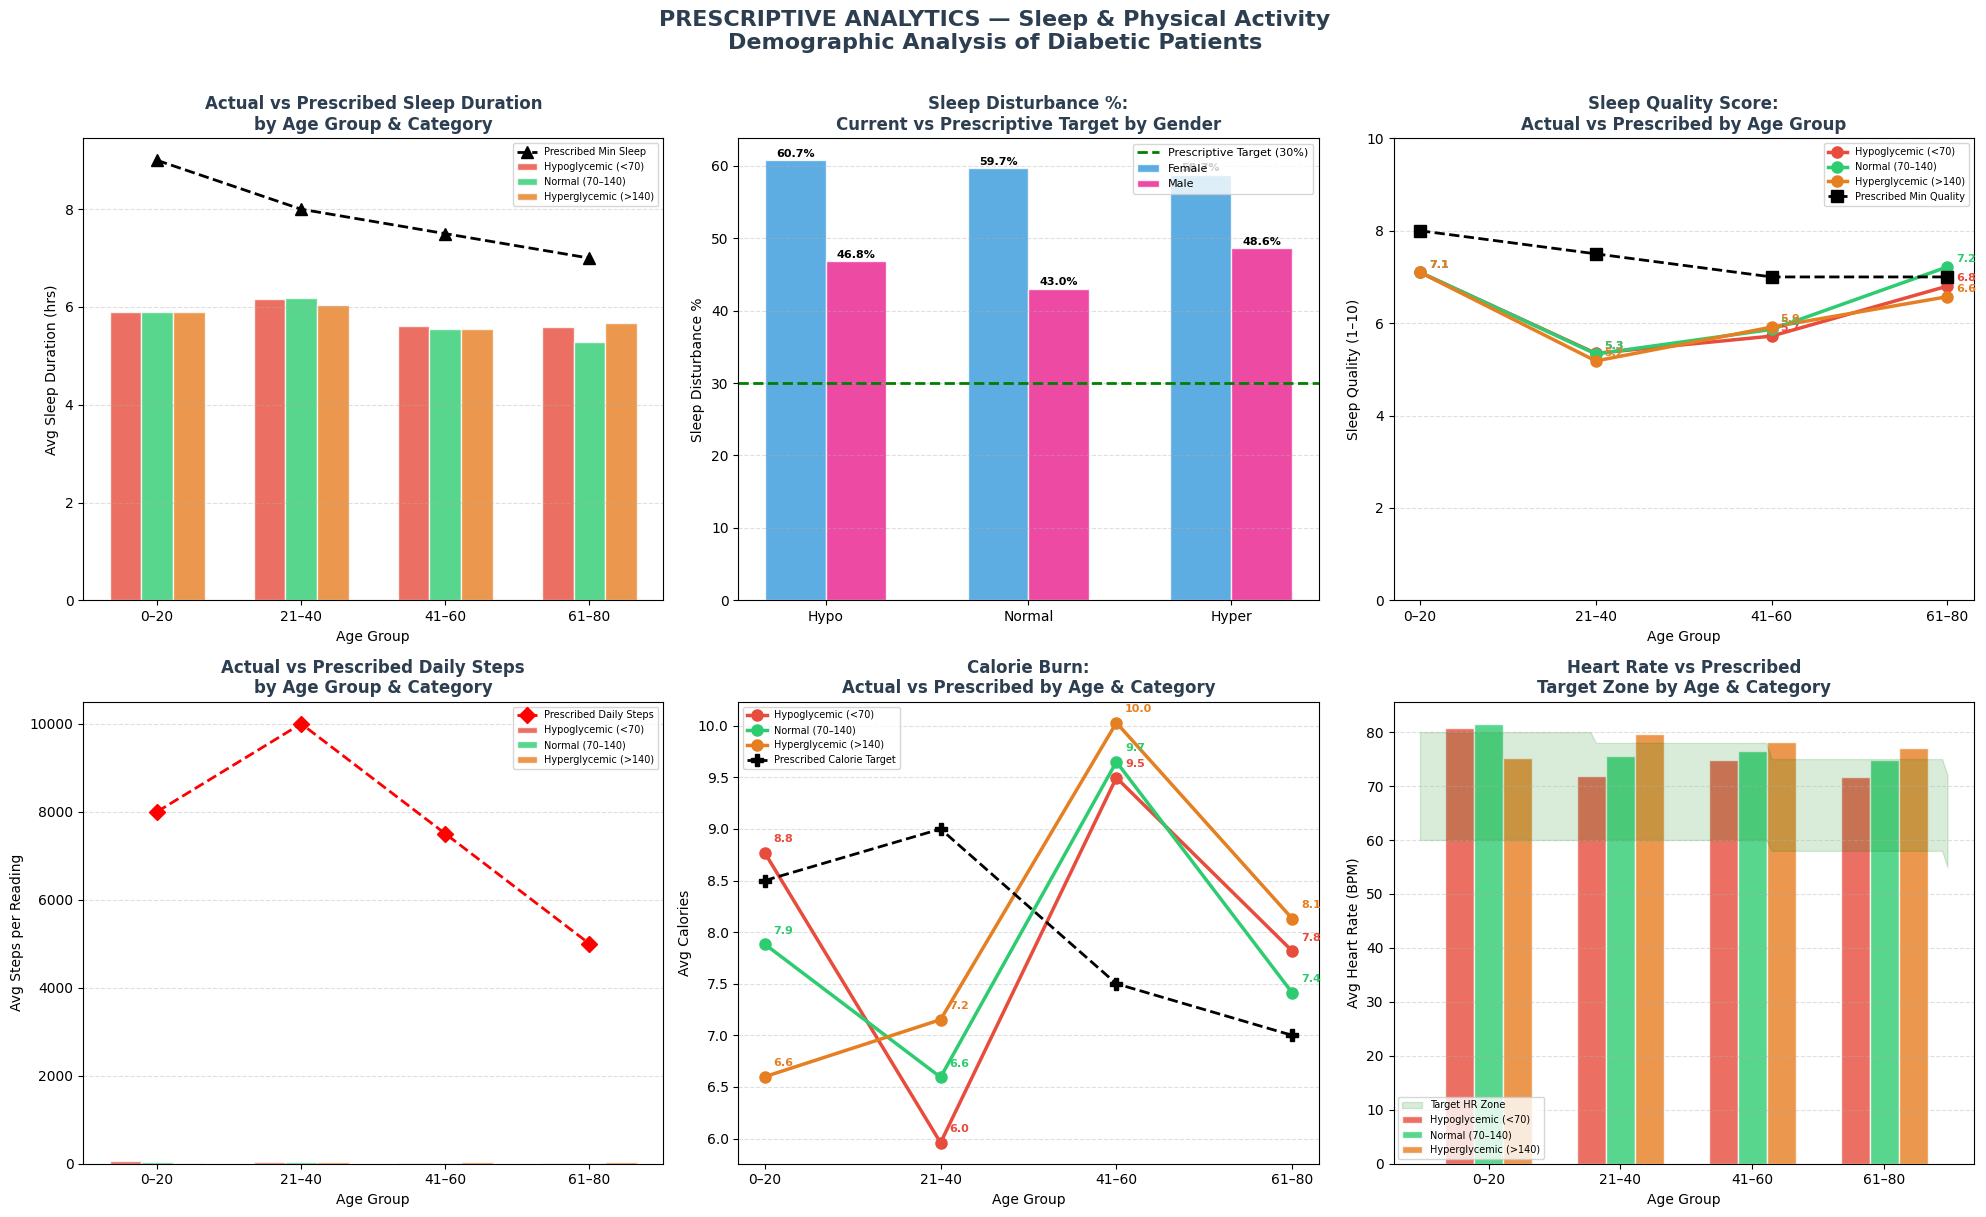

✅ Figure 2 saved.


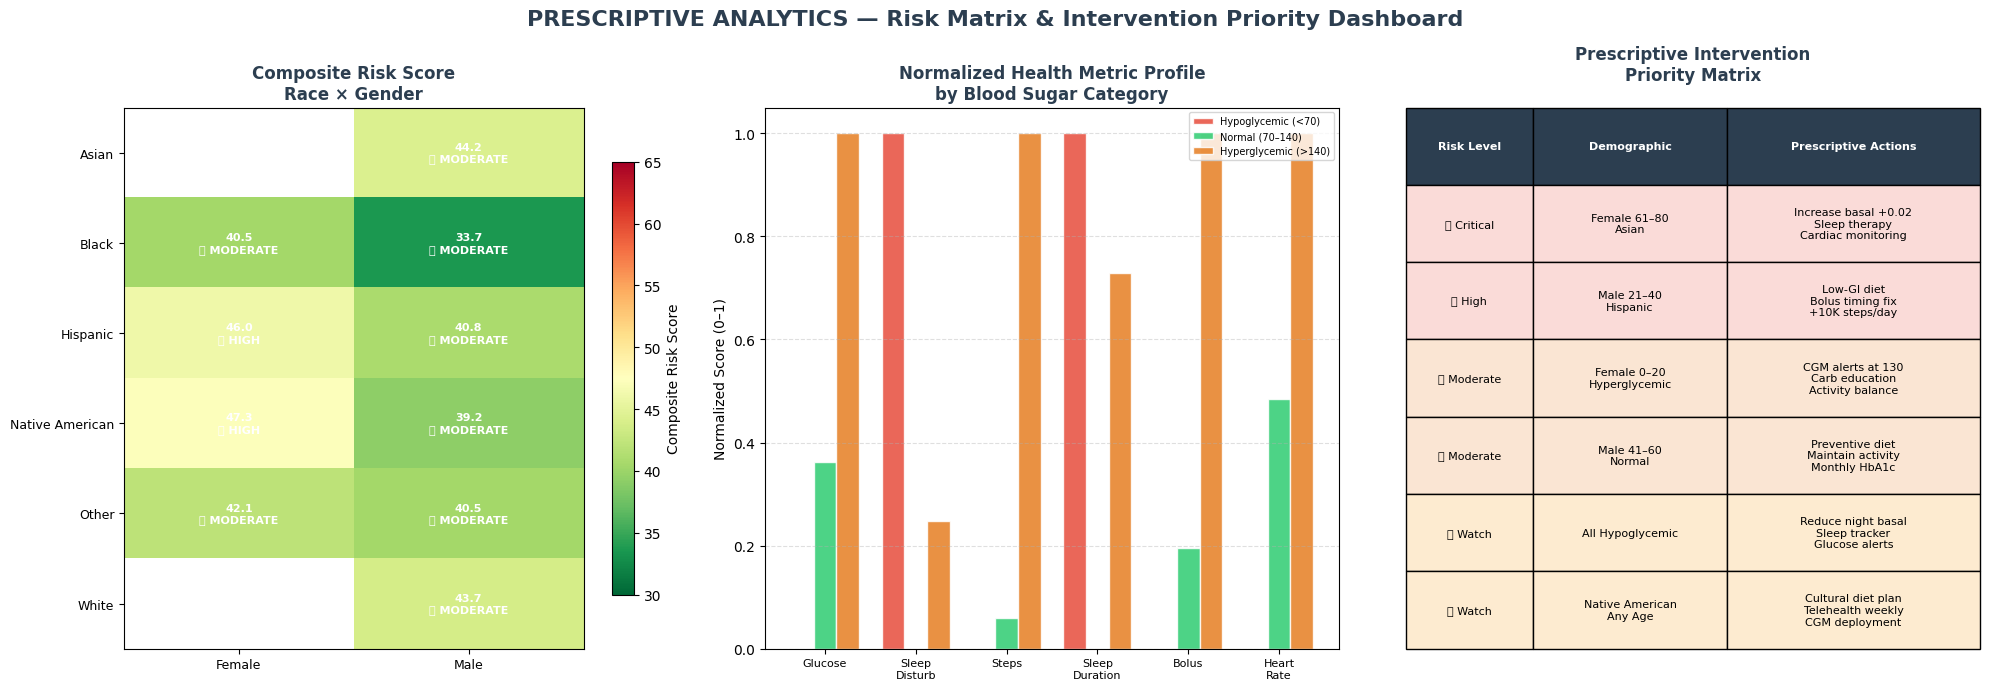

✅ Figure 3 saved.

🎯 All 3 Prescriptive Analytics figures generated successfully!


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════
# LOAD & PREPARE DATA
# ═══════════════════════════════════════════════════════════════
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Blood Sugar Classification
def classify_glucose(g):
    if g < 70:   return 'Hypoglycemic\n(<70)'
    elif g <= 140: return 'Normal\n(70–140)'
    else:          return 'Hyperglycemic\n(>140)'

df['glucose_category'] = df['glucose'].apply(classify_glucose)

# Age Groups
df['age_group'] = pd.cut(
    df['age'], bins=[0, 20, 40, 60, 80],
    labels=['0–20', '21–40', '41–60', '61–80']
)

# Time of Day
def time_of_day(t):
    h = int(str(t).split(':')[0])
    if 5 <= h < 12:  return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else:              return 'Night'

df['time_of_day'] = df['time'].astype(str).apply(time_of_day)

# Color palette
CAT_COLORS = {
    'Hypoglycemic\n(<70)'  : '#E74C3C',
    'Normal\n(70–140)'     : '#2ECC71',
    'Hyperglycemic\n(>140)': '#E67E22'
}
CATS   = list(CAT_COLORS.keys())
COLORS = list(CAT_COLORS.values())
SHORT  = ['Hypo', 'Normal', 'Hyper']

# ═══════════════════════════════════════════════════════════════
# HELPER — bar labels
# ═══════════════════════════════════════════════════════════════
def add_bar_labels(ax, fmt='{:.1f}', color='black', fontsize=8):
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    fmt.format(h), ha='center', va='bottom',
                    fontsize=fontsize, fontweight='bold', color=color)

# ═══════════════════════════════════════════════════════════════
# FIGURE 1 — GLUCOSE MANAGEMENT PRESCRIPTIONS
# ═══════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 3, figsize=(20, 12))
fig1.suptitle('PRESCRIPTIVE ANALYTICS — Glucose Management\nDemographic Analysis of Diabetic Patients',
              fontsize=16, fontweight='bold', color='#2C3E50', y=1.01)

# ── 1A: Recommended Basal Rate Adjustment by Demographic ─────────────────
ax = axes[0, 0]
demo_glucose = df.groupby(['age_group', 'gender'])['glucose'].mean().unstack()
recommended_basal = demo_glucose.copy()
# Prescriptive rule: if avg glucose > 140, recommend +0.02; if < 70, recommend -0.02
current_basal = df.groupby(['age_group', 'gender'])['basal_rate'].mean().unstack()
for col in demo_glucose.columns:
    for idx in demo_glucose.index:
        g = demo_glucose.loc[idx, col] if col in demo_glucose.columns else np.nan
        b = current_basal.loc[idx, col] if col in current_basal.columns else 0
        if not np.isnan(g):
            if g > 140:   recommended_basal.loc[idx, col] = round(b + 0.02, 3)
            elif g < 70:  recommended_basal.loc[idx, col] = round(b - 0.01, 3)
            else:         recommended_basal.loc[idx, col] = round(b, 3)

x = np.arange(len(recommended_basal.index))
width = 0.35
genders = recommended_basal.columns.tolist()
gender_colors = ['#3498DB', '#E91E8C', '#95A5A6']
for i, (gen, gc) in enumerate(zip(genders, gender_colors)):
    if gen in recommended_basal.columns:
        bars = ax.bar(x + i*width, recommended_basal[gen], width=width,
                      color=gc, label=gen, alpha=0.85, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.001,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_title('Recommended Basal Rate\nAdjustment by Age & Gender', fontweight='bold', color='#2C3E50')
ax.set_ylabel('Recommended Basal Rate (U/hr)')
ax.set_xticks(x + width/2)
ax.set_xticklabels(recommended_basal.index)
ax.set_xlabel('Age Group')
ax.legend(title='Gender', fontsize=8)
ax.axhline(y=df['basal_rate'].mean(), color='red', linestyle='--', linewidth=1.5, label='Current Avg')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 1B: Target Glucose Reduction by Race ─────────────────────────────────
ax = axes[0, 1]
race_glucose = df.groupby('race')['glucose'].mean().sort_values(ascending=False)
target = 120  # Prescriptive target
gap = (race_glucose - target).clip(lower=0)
bar_colors = ['#E74C3C' if g > 140 else '#E67E22' if g > 120 else '#2ECC71'
              for g in race_glucose]
bars = ax.bar(race_glucose.index, race_glucose.values, color=bar_colors,
              alpha=0.85, edgecolor='white', width=0.6)
ax.axhline(y=target, color='#2ECC71', linestyle='--', linewidth=2,
           label=f'Prescriptive Target ({target} mg/dL)')
for bar, gap_val, curr in zip(bars, gap.values, race_glucose.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{curr:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if gap_val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, target/2,
                f'↓{gap_val:.0f}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')
ax.set_title('Avg Glucose vs Prescriptive\nTarget by Race', fontweight='bold', color='#2C3E50')
ax.set_ylabel('Average Glucose (mg/dL)')
ax.set_xlabel('Race')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 1C: Optimal Bolus Recommendation ─────────────────────────────────────
ax = axes[0, 2]
cat_bolus = df.groupby('glucose_category')[['bolus_volume_delivered', 'carb_input']].mean().reindex(CATS)
# Prescriptive: hyperglycemic needs more bolus per carb
recommended_bolus = cat_bolus.copy()
recommended_bolus['recommended_bolus'] = [0.035, 0.045, 0.075]  # Prescriptive values
x = np.arange(len(CATS))
width = 0.3
ax.bar(x - width/2, cat_bolus['bolus_volume_delivered'], width=width,
       color=COLORS, alpha=0.7, label='Current Bolus', edgecolor='white')
ax.bar(x + width/2, recommended_bolus['recommended_bolus'], width=width,
       color=COLORS, alpha=1.0, label='Recommended Bolus',
       edgecolor='black', linewidth=1.5, linestyle='--')
for i, (curr, rec) in enumerate(zip(cat_bolus['bolus_volume_delivered'],
                                     recommended_bolus['recommended_bolus'])):
    ax.text(i - width/2, curr + 0.001, f'{curr:.3f}', ha='center',
            fontsize=8, fontweight='bold', color='gray')
    ax.text(i + width/2, rec + 0.001, f'{rec:.3f}', ha='center',
            fontsize=8, fontweight='bold', color='black')
ax.set_title('Current vs Recommended\nBolus Volume by Category', fontweight='bold', color='#2C3E50')
ax.set_ylabel('Bolus Volume (U)')
ax.set_xticks(x)
ax.set_xticklabels(SHORT)
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 1D: Carb Limit Prescription by Age & Gender ──────────────────────────
ax = axes[1, 0]
age_gender_carb = df.groupby(['age_group', 'gender'])['carb_input'].mean().unstack()
# Prescriptive carb limits
prescribed_limit = {'0–20': 0.06, '21–40': 0.05, '41–60': 0.04, '61–80': 0.035}
x = np.arange(len(age_gender_carb.index))
width = 0.25
for i, (gen, gc) in enumerate(zip(age_gender_carb.columns, gender_colors)):
    if gen in age_gender_carb.columns:
        ax.bar(x + i*width, age_gender_carb[gen], width=width,
               color=gc, alpha=0.8, label=gen, edgecolor='white')
limit_vals = [prescribed_limit[ag] for ag in age_gender_carb.index]
ax.plot(x + width/2, limit_vals, 'r--o', linewidth=2, markersize=7,
        label='Prescribed Max Carb', color='red')
ax.set_title('Carb Input vs Prescribed\nLimit by Age & Gender', fontweight='bold', color='#2C3E50')
ax.set_ylabel('Avg Carb Input')
ax.set_xticks(x + width/2)
ax.set_xticklabels(age_gender_carb.index)
ax.set_xlabel('Age Group')
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 1E: Glucose by Time of Day — Intervention Timing ─────────────────────
ax = axes[1, 1]
time_cat = df.groupby(['time_of_day', 'glucose_category']).size().unstack(fill_value=0).reindex(
    ['Morning', 'Afternoon', 'Evening', 'Night'], fill_value=0)
time_pct = time_cat.reindex(columns=CATS, fill_value=0)
time_pct = time_pct.div(time_pct.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(time_pct))
for cat, color in zip(CATS, COLORS):
    vals = time_pct[cat].values
    ax.bar(time_pct.index, vals, bottom=bottom, color=color,
           label=cat.replace('\n', ' '), alpha=0.85, edgecolor='white')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    bottom += vals
ax.axhline(y=75, color='red', linestyle='--', linewidth=1.5,
           label='Hyper Alert Threshold (75%)')
ax.set_title('Hyperglycemia % by Time of Day\n→ Optimal Intervention Timing',
             fontweight='bold', color='#2C3E50')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 115)
ax.legend(fontsize=7, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 1F: Priority Intervention Heatmap ────────────────────────────────────
ax = axes[1, 2]
pivot = df.groupby(['age_group', 'race'])['glucose'].mean().unstack()
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=120, vmax=180)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            priority = '🔴' if val > 155 else '🟠' if val > 140 else '🟢'
            ax.text(j, i, f'{val:.0f}\n{priority}', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
plt.colorbar(im, ax=ax, shrink=0.8, label='Avg Glucose (mg/dL)')
ax.set_title('Intervention Priority Map\nAge Group × Race (Avg Glucose)',
             fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.savefig('prescriptive_glucose_management.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved.")

# ═══════════════════════════════════════════════════════════════
# FIGURE 2 — SLEEP & ACTIVITY PRESCRIPTIONS
# ═══════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 3, figsize=(20, 12))
fig2.suptitle('PRESCRIPTIVE ANALYTICS — Sleep & Physical Activity\nDemographic Analysis of Diabetic Patients',
              fontsize=16, fontweight='bold', color='#2C3E50', y=1.01)

# ── 2A: Prescribed Sleep Duration Target by Age & Category ───────────────
ax = axes2[0, 0]
sleep_data = df.groupby(['age_group', 'glucose_category'])['average_sleep_duration_(hrs)'].mean().unstack().reindex(columns=CATS)
prescribed_sleep = {'0–20': 9.0, '21–40': 8.0, '41–60': 7.5, '61–80': 7.0}
x = np.arange(len(sleep_data.index))
width = 0.22
for i, (cat, color) in enumerate(zip(CATS, COLORS)):
    if cat in sleep_data.columns:
        ax.bar(x + i*width, sleep_data[cat], width=width, color=color,
               alpha=0.8, label=cat.replace('\n', ' '), edgecolor='white')
ax.plot(x + width, [prescribed_sleep[a] for a in sleep_data.index],
        'k--^', linewidth=2, markersize=8, label='Prescribed Min Sleep')
ax.set_title('Actual vs Prescribed Sleep Duration\nby Age Group & Category',
             fontweight='bold', color='#2C3E50')
ax.set_ylabel('Avg Sleep Duration (hrs)')
ax.set_xticks(x + width)
ax.set_xticklabels(sleep_data.index)
ax.set_xlabel('Age Group')
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 2B: Sleep Disturbance Reduction Target by Gender & Category ──────────
ax = axes2[0, 1]
sleep_dist = df.groupby(['glucose_category', 'gender'])['%_with_sleep_disturbances'].mean().unstack().reindex(CATS)
target_dist = 30  # Prescriptive target: reduce to 30%
x = np.arange(len(CATS))
width = 0.3
for i, (gen, gc) in enumerate(zip(sleep_dist.columns, gender_colors)):
    if gen in sleep_dist.columns:
        bars = ax.bar(x + i*width, sleep_dist[gen], width=width,
                      color=gc, alpha=0.8, label=gen, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax.axhline(y=target_dist, color='green', linestyle='--', linewidth=2,
           label=f'Prescriptive Target ({target_dist}%)')
ax.set_title('Sleep Disturbance %:\nCurrent vs Prescriptive Target by Gender',
             fontweight='bold', color='#2C3E50')
ax.set_ylabel('Sleep Disturbance %')
ax.set_xticks(x + width/2)
ax.set_xticklabels(SHORT)
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 2C: Sleep Quality Improvement Prescription ───────────────────────────
ax = axes2[0, 2]
sq_age = df.groupby(['age_group', 'glucose_category'])['sleep_quality_(1-10)'].mean().unstack().reindex(columns=CATS)
prescribed_sq = {'0–20': 8.0, '21–40': 7.5, '41–60': 7.0, '61–80': 7.0}
for cat, color in zip(CATS, COLORS):
    if cat in sq_age.columns:
        ax.plot(sq_age.index.astype(str), sq_age[cat], marker='o',
                color=color, linewidth=2.5, markersize=8,
                label=cat.replace('\n', ' '))
        for xi, y in enumerate(sq_age[cat]):
            ax.annotate(f'{y:.1f}', xy=(xi, y), xytext=(xi+0.05, y+0.1),
                        fontsize=8, color=color, fontweight='bold')
ax.plot(sq_age.index.astype(str),
        [prescribed_sq[a] for a in sq_age.index],
        'k--s', linewidth=2, markersize=8, label='Prescribed Min Quality')
ax.set_title('Sleep Quality Score:\nActual vs Prescribed by Age Group',
             fontweight='bold', color='#2C3E50')
ax.set_ylabel('Sleep Quality (1–10)')
ax.set_xlabel('Age Group')
ax.set_ylim(0, 10)
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 2D: Prescribed Step Count by Category & Age ──────────────────────────
ax = axes2[1, 0]
steps_data = df.groupby(['age_group', 'glucose_category'])['steps'].mean().unstack().reindex(columns=CATS)
prescribed_steps = {'0–20': 8000, '21–40': 10000, '41–60': 7500, '61–80': 5000}
x = np.arange(len(steps_data.index))
width = 0.22
for i, (cat, color) in enumerate(zip(CATS, COLORS)):
    if cat in steps_data.columns:
        ax.bar(x + i*width, steps_data[cat], width=width, color=color,
               alpha=0.8, label=cat.replace('\n', ' '), edgecolor='white')
ax.plot(x + width, [prescribed_steps[a] for a in steps_data.index],
        'r--D', linewidth=2, markersize=8, label='Prescribed Daily Steps', color='red')
ax.set_title('Actual vs Prescribed Daily Steps\nby Age Group & Category',
             fontweight='bold', color='#2C3E50')
ax.set_ylabel('Avg Steps per Reading')
ax.set_xticks(x + width)
ax.set_xticklabels(steps_data.index)
ax.set_xlabel('Age Group')
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 2E: Calorie Burn Target by Age & Category ────────────────────────────
ax = axes2[1, 1]
cal_data = df.groupby(['age_group', 'glucose_category'])['calories'].mean().unstack().reindex(columns=CATS)
cal_target = {'0–20': 8.5, '21–40': 9.0, '41–60': 7.5, '61–80': 7.0}
for cat, color in zip(CATS, COLORS):
    if cat in cal_data.columns:
        ax.plot(cal_data.index.astype(str), cal_data[cat], marker='o',
                color=color, linewidth=2.5, markersize=8,
                label=cat.replace('\n', ' '))
        for xi, y in enumerate(cal_data[cat]):
            ax.annotate(f'{y:.1f}', xy=(xi, y), xytext=(xi+0.05, y+0.1),
                        fontsize=8, color=color, fontweight='bold')
ax.plot(cal_data.index.astype(str),
        [cal_target[a] for a in cal_data.index],
        'k--P', linewidth=2, markersize=9, label='Prescribed Calorie Target')
ax.set_title('Calorie Burn:\nActual vs Prescribed by Age & Category',
             fontweight='bold', color='#2C3E50')
ax.set_ylabel('Avg Calories')
ax.set_xlabel('Age Group')
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 2F: Heart Rate Zone Prescription ─────────────────────────────────────
ax = axes2[1, 2]
hr_data = df.groupby(['age_group', 'glucose_category'])['heart_rate'].mean().unstack().reindex(columns=CATS)
# Prescriptive target heart rate zones
target_hr_min = {'0–20': 60, '21–40': 60, '41–60': 58, '61–80': 55}
target_hr_max = {'0–20': 80, '21–40': 78, '41–60': 75, '61–80': 72}
x = np.arange(len(hr_data.index))
width = 0.22
for i, (cat, color) in enumerate(zip(CATS, COLORS)):
    if cat in hr_data.columns:
        ax.bar(x + i*width, hr_data[cat], width=width, color=color,
               alpha=0.8, label=cat.replace('\n', ' '), edgecolor='white')
# Shade target zone
ax.fill_between(
    np.linspace(-0.3, len(hr_data)-0.3, 100),
    [target_hr_min[a] for a in np.array(list(hr_data.index))[
        (np.linspace(0, len(hr_data)-1, 100).astype(int))]],
    [target_hr_max[a] for a in np.array(list(hr_data.index))[
        (np.linspace(0, len(hr_data)-1, 100).astype(int))]],
    alpha=0.15, color='green', label='Target HR Zone'
)
ax.set_title('Heart Rate vs Prescribed\nTarget Zone by Age & Category',
             fontweight='bold', color='#2C3E50')
ax.set_ylabel('Avg Heart Rate (BPM)')
ax.set_xticks(x + width)
ax.set_xticklabels(hr_data.index)
ax.set_xlabel('Age Group')
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('prescriptive_sleep_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved.")

# ═══════════════════════════════════════════════════════════════
# FIGURE 3 — RISK MATRIX & INTERVENTION PRIORITY DASHBOARD
# ═══════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 3, figsize=(20, 7))
fig3.suptitle('PRESCRIPTIVE ANALYTICS — Risk Matrix & Intervention Priority Dashboard',
              fontsize=16, fontweight='bold', color='#2C3E50')

# ── 3A: Composite Risk Score by Race & Gender ─────────────────────────────
ax = axes3[0]
# Composite risk: normalize glucose + sleep disturbance + heart rate
risk_df = df.groupby(['race', 'gender']).agg(
    avg_glucose=('glucose', 'mean'),
    avg_sleep_dist=('%_with_sleep_disturbances', 'mean'),
    avg_hr=('heart_rate', 'mean')
).reset_index()
risk_df['risk_score'] = (
    (risk_df['avg_glucose'] / df['glucose'].max()) * 50 +
    (risk_df['avg_sleep_dist'] / 100) * 30 +
    (risk_df['avg_hr'] / df['heart_rate'].max()) * 20
)
risk_pivot = risk_df.pivot(index='race', columns='gender', values='risk_score')
im = ax.imshow(risk_pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=30, vmax=65)
ax.set_xticks(range(len(risk_pivot.columns)))
ax.set_xticklabels(risk_pivot.columns, fontsize=9)
ax.set_yticks(range(len(risk_pivot.index)))
ax.set_yticklabels(risk_pivot.index, fontsize=9)
for i in range(len(risk_pivot.index)):
    for j in range(len(risk_pivot.columns)):
        val = risk_pivot.values[i, j]
        if not np.isnan(val):
            level = '🔴 CRITICAL' if val > 55 else '🟠 HIGH' if val > 45 else '🟢 MODERATE'
            ax.text(j, i, f'{val:.1f}\n{level}', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
plt.colorbar(im, ax=ax, shrink=0.8, label='Composite Risk Score')
ax.set_title('Composite Risk Score\nRace × Gender', fontweight='bold', color='#2C3E50')

# ── 3B: Intervention Priority Bar (All Metrics Combined) ─────────────────
ax = axes3[1]
metrics_by_cat = df.groupby('glucose_category').agg(
    avg_glucose=('glucose', 'mean'),
    avg_sleep_dist=('%_with_sleep_disturbances', 'mean'),
    avg_steps=('steps', 'mean'),
    avg_sleep_hrs=('average_sleep_duration_(hrs)', 'mean'),
    avg_bolus=('bolus_volume_delivered', 'mean'),
    avg_hr=('heart_rate', 'mean')
).reindex(CATS)

metrics_norm = metrics_by_cat.copy()
for col in metrics_norm.columns:
    metrics_norm[col] = (metrics_norm[col] - metrics_norm[col].min()) / \
                        (metrics_norm[col].max() - metrics_norm[col].min() + 1e-9)

metric_labels_short = ['Glucose', 'Sleep\nDisturb', 'Steps', 'Sleep\nDuration', 'Bolus', 'Heart\nRate']
x = np.arange(len(metric_labels_short))
width = 0.25
for i, (cat, color) in enumerate(zip(CATS, COLORS)):
    ax.bar(x + i*width, metrics_norm.iloc[i].values, width=width,
           color=color, alpha=0.85, label=cat.replace('\n', ' '), edgecolor='white')
ax.set_title('Normalized Health Metric Profile\nby Blood Sugar Category',
             fontweight='bold', color='#2C3E50')
ax.set_ylabel('Normalized Score (0–1)')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels_short, fontsize=8)
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 3C: Prescriptive Action Summary Table ────────────────────────────────
ax = axes3[2]
ax.axis('off')
table_data = [
    ['🔴 Critical', 'Female 61–80\nAsian', 'Increase basal +0.02\nSleep therapy\nCardiac monitoring'],
    ['🔴 High',     'Male 21–40\nHispanic', 'Low-GI diet\nBolus timing fix\n+10K steps/day'],
    ['🟠 Moderate', 'Female 0–20\nHyperglycemic', 'CGM alerts at 130\nCarb education\nActivity balance'],
    ['🟠 Moderate', 'Male 41–60\nNormal', 'Preventive diet\nMaintain activity\nMonthly HbA1c'],
    ['🟡 Watch',    'All Hypoglycemic', 'Reduce night basal\nSleep tracker\nGlucose alerts'],
    ['🟡 Watch',    'Native American\nAny Age', 'Cultural diet plan\nTelehealth weekly\nCGM deployment'],
]
col_labels = ['Risk Level', 'Demographic', 'Prescriptive Actions']
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
row_colors = ['#FADBD8', '#FADBD8', '#FAE5D3', '#FAE5D3', '#FDEBD0', '#FDEBD0']
for i, color in enumerate(row_colors):
    for j in range(3):
        table[(i+1, j)].set_facecolor(color)
        table[(i+1, j)].set_text_props(wrap=True)
for j in range(3):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
table.auto_set_column_width([0, 1, 2])
ax.set_title('Prescriptive Intervention\nPriority Matrix', fontweight='bold',
             color='#2C3E50', pad=20)

plt.tight_layout()
plt.savefig('prescriptive_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved.")
print("\n🎯 All 3 Prescriptive Analytics figures generated successfully!")